In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "duration_ms",
    "instrumentalness",
    "affinity"
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize().insert_some_tracks(df_1, 0.5, 0.5)[0].randomize(["affinity"]).shuffle()

df = df_1.merge(df_2)

display(df.data)

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Hope drug,owen,1.042200,0.931460,0.755748,1.213691
1,Ask control,owen,0.814931,1.073540,1.020805,0.994034
2,Page character,owen,0.983883,1.005483,1.068421,0.984075
3,Improve,owen,0.936508,0.954324,0.940248,0.845187
4,Break alone,owen,0.951016,1.004414,0.973392,0.820610
5,Once drive,paul,0.965690,1.051820,0.872528,0.891451
6,Page character,paul,0.983883,1.005483,1.068421,0.924561
7,Mouth anything,paul,1.106982,1.070198,1.033231,1.052697
8,Fact hope,paul,1.028129,1.078095,0.960603,0.966301
9,Hope drug,paul,1.042200,0.931460,0.755748,0.886571


In [4]:
df = generate_dataset_with_similarities(
    num_users=25,
    n_samples=150,
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.8,
    min_track_mixing_percentage=0.9,
    mix_with_someone_else_chance=0.8,
)
df.data

Mixing user Casey Shepard with Stephanie Miller with a replacement percentage of 84.00%
Mixing user Clarence Hooper with Jason Phillips with a replacement percentage of 86.67%
Mixing user Heather Ruiz with Tommy Sloan with a replacement percentage of 84.67%
Mixing user Michele Diaz with Jason Phillips with a replacement percentage of 83.33%
Mixing user Kristina Parsons with Chad Moore with a replacement percentage of 82.00%
Mixing user Jason Phillips with Chad Moore with a replacement percentage of 85.33%
Mixing user Cassandra Pearson with Linda Hall with a replacement percentage of 85.33%
Mixing user Oscar Gibson with Samantha Rogers with a replacement percentage of 86.67%
Mixing user Robert Wilson with Jason Phillips with a replacement percentage of 88.67%
Mixing user Elizabeth Chang with Clarence Hooper with a replacement percentage of 84.67%
Mixing user Ruth May with Kristina Parsons with a replacement percentage of 89.33%
Mixing user Tommy Sloan with Michele Diaz with a replacemen

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Again might,Tammy Adams,1.039241,0.964523,1.006833,1.037543
1,Series section,Tammy Adams,1.178141,1.336991,1.116079,0.941520
2,Which white,Tammy Adams,1.012831,0.847964,0.891829,0.865147
3,Improve vote,Tammy Adams,1.018040,0.801232,1.129791,1.018369
4,Like than east,Tammy Adams,1.034227,0.825906,0.941141,0.997609
...,...,...,...,...,...,...
3745,Happen trip,Chad Moore,0.957995,0.979026,0.946904,1.057026
3746,Business night,Chad Moore,0.926246,1.249290,1.098957,0.744143
3747,Follow,Chad Moore,1.090594,1.131918,1.109606,1.071262
3748,Assume line,Chad Moore,1.151250,0.940696,0.847067,0.927352


In [6]:
df.data.to_csv("data/artificial_data_df.csv")

In [ ]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Amanda Lucas,Amy Shaw,Andrew Doyle,Anna Higgins,Anna Robinson,Benjamin Thomas,Billy Giles,Billy Kelly,David Hernandez,Deborah Payne,...,Kathryn White,Keith Patton,Mario Nelson,Mark Blackburn,Megan Leonard,Melanie Berry,Michael Wheeler,Michelle Suarez,Paige Lowe,Zachary Steele
username,,,,,,,,,,,,,,,,,,,,,
Amanda Lucas,1.000000,0.013333,0.013333,0.013333,0.020000,0.020000,0.020000,0.020000,0.020000,0.726667,...,0.000000,0.006667,0.006667,0.013333,0.013333,0.006667,0.020000,0.013333,0.020000,0.013333
Amy Shaw,0.013333,1.026667,0.926667,0.833333,0.006667,0.100000,0.080000,0.000000,0.093333,0.013333,...,0.020000,0.093333,0.066667,0.086667,0.006667,0.013333,0.013333,0.060000,0.013333,0.006667
Andrew Doyle,0.013333,0.926667,1.040000,0.926667,0.006667,0.006667,0.020000,0.000000,0.013333,0.013333,...,0.020000,0.113333,0.086667,0.006667,0.006667,0.020000,0.006667,0.006667,0.006667,0.006667
Anna Higgins,0.013333,0.833333,0.926667,1.040000,0.013333,0.000000,0.006667,0.000000,0.000000,0.013333,...,0.020000,0.133333,0.000000,0.006667,0.013333,0.013333,0.006667,0.000000,0.006667,0.020000
Anna Robinson,0.020000,0.006667,0.006667,0.013333,1.013333,0.006667,0.006667,0.006667,0.006667,0.013333,...,0.026667,0.006667,0.000000,0.013333,0.833333,0.013333,0.013333,0.006667,0.013333,0.693333
Benjamin Thomas,0.020000,0.100000,0.006667,0.000000,0.006667,1.026667,0.646667,0.006667,0.760000,0.020000,...,0.013333,0.020000,0.020000,0.840000,0.006667,0.000000,0.040000,0.720000,0.040000,0.013333
Billy Giles,0.020000,0.080000,0.020000,0.006667,0.006667,0.646667,1.026667,0.006667,0.866667,0.013333,...,0.013333,0.026667,0.020000,0.526667,0.006667,0.006667,0.040000,0.433333,0.040000,0.013333
Billy Kelly,0.020000,0.000000,0.000000,0.000000,0.006667,0.006667,0.006667,1.000000,0.006667,0.026667,...,0.020000,0.026667,0.020000,0.000000,0.006667,0.020000,0.020000,0.020000,0.013333,0.006667
David Hernandez,0.020000,0.093333,0.013333,0.000000,0.006667,0.760000,0.866667,0.006667,1.026667,0.020000,...,0.013333,0.040000,0.020000,0.613333,0.006667,0.006667,0.040000,0.520000,0.040000,0.013333


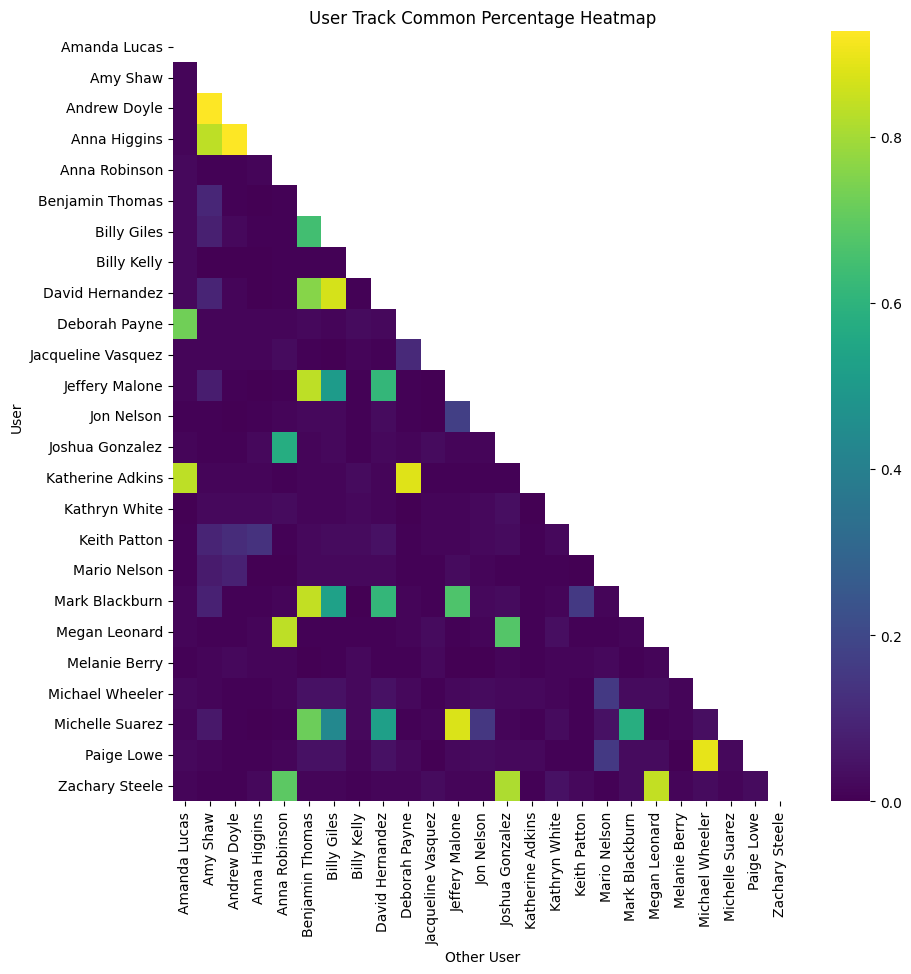

In [ ]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10))

In [ ]:
df.data.to_csv(os.path.join("data", "artificial_data.csv"))

In [ ]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([25, 1878])